In [127]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set_style("whitegrid")

In [128]:
def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 9,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })



In [129]:
# set this to your actual file
result_path = Path("sensitivity/simulation_mm_sensitivity/Two_completely_crossed_random_effects/crossed/simulation_results_python.pkl")  # 001
# One_random_effect/001/simulation_results_python.pkl
# Two_completely_crossed_random_effects/crossed/simulation_results_python.pkl
with open(result_path, "rb") as f:
    obj = pickle.load(f)

obj.keys()

dict_keys(['config', 'results'])

In [130]:
config = obj["config"]
results = obj["results"]

print(config.keys())
print(list(results.keys())[:5])

dict_keys(['data_generation', 'models', 'replicate', 'n_groups', 'group_size', 'likelihood', 'randeff', 'estimate_hyper', 'delta_logl_values', 'alpha', 'target_quantile', 'gpb_approxs', 'all_models', 'likelihood_dict'])
['ald_100_100', 'ald_100_500', 'gaussian_100_100', 'gaussian_100_500', 't_100_100']


In [131]:
rows = []

for config_key, rep_dict in results.items():
    # config_key like "ald_100_500"
    likelihood, n_group, group_size = config_key.split("_")
    n_group = int(n_group)
    group_size = int(group_size)

    for replicate, model_dict in rep_dict.items():
        for model_name, metrics in model_dict.items():
            hyper = metrics.get("hyper_params", None)

            row = {
                "config_key": config_key,
                "replicate": replicate,
                "likelihood": likelihood,
                "n_group": n_group,
                "group_size": group_size,
                "model": model_name,
                "delta_logl": metrics.get("delta_logl", np.nan),
                "rmse": metrics.get("rmse", np.nan),
                "quantile_loss": metrics.get("quantile_loss", np.nan),
                "coverage": metrics.get("coverage", np.nan),
                "width": metrics.get("width", np.nan),
                "time": metrics.get("time", np.nan),
                "hyper_params_raw": metrics.get("hyper_params", None)
            }

            if isinstance(hyper, dict):
                for k, v in hyper.items():
                    row[f"hyper_{k}"] = v

            rows.append(row)

            

df = pd.DataFrame(rows)
df.head()

,config_key,replicate,likelihood,n_group,group_size,model,delta_logl,rmse,quantile_loss,coverage,width,time,hyper_params_raw,hyper_Group_1,hyper_Group_2,hyper_noise_variance
0,ald_100_100,2,ald,100,100,gpboost_cc_dll_0.01,0.01,0.093494,0.091194,0.70425,0.187613,3.143608,"{'Group_1': 0.7023239369087798, 'Group_2': 1.0...",0.702324,1.008836,0.082258
1,ald_100_100,2,ald,100,100,gpboost_cc_dll_0.03,0.03,0.093494,0.091194,0.70425,0.187613,3.371027,"{'Group_1': 0.7023239369087798, 'Group_2': 1.0...",0.702324,1.008836,0.082258
2,ald_100_100,2,ald,100,100,gpboost_cc_dll_0.1,0.10,0.093494,0.091194,0.70425,0.187613,3.425676,"{'Group_1': 0.7023239369087798, 'Group_2': 1.0...",0.702324,1.008836,0.082258
3,ald_100_100,2,ald,100,100,gpboost_cc_dll_0.3,0.30,0.093494,0.091194,0.70425,0.187613,3.405940,"{'Group_1': 0.7023239369087798, 'Group_2': 1.0...",0.702324,1.008836,0.082258
4,ald_100_100,2,ald,100,100,gpboost_cc_dll_1.0,1.00,0.093494,0.091194,0.70425,0.187613,3.657640,"{'Group_1': 0.7023239369087798, 'Group_2': 1.0...",0.702324,1.008836,0.082258


In [132]:
# just in case delta_logl got stored as strings somewhere
df["delta_logl"] = pd.to_numeric(df["delta_logl"], errors="coerce")
df = df.sort_values(["likelihood", "group_size", "delta_logl", "replicate"]).reset_index(drop=True)

df.shape

(300, 16)

In [133]:
summary = (
    df.groupby(["likelihood", "group_size", "delta_logl"], as_index=False)
      .agg(
          rmse_mean=("rmse", "mean"),
          rmse_se=("rmse", lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
          time_mean=("time", "mean"),
          time_se=("time", lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
          qloss_mean=("quantile_loss", "mean"),
          qloss_se=("quantile_loss", lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
      )
)

summary.head()

,likelihood,group_size,delta_logl,rmse_mean,rmse_se,time_mean,time_se,qloss_mean,qloss_se
0,ald,100,0.01,0.092726,0.001704,4.048392,0.292515,0.092661,0.000367
1,ald,100,0.03,0.092726,0.001704,4.219426,0.264254,0.092661,0.000367
2,ald,100,0.10,0.092726,0.001704,4.176028,0.277832,0.092661,0.000367
3,ald,100,0.30,0.092726,0.001704,4.367686,0.328280,0.092661,0.000367
4,ald,100,1.00,0.092641,0.001700,4.428883,0.331046,0.092650,0.000364


In [134]:
def plot_metric(summary_df, metric_mean, metric_se, ylabel):
    set_style()
    likelihoods = sorted(summary_df["likelihood"].unique())
    group_sizes = sorted(summary_df["group_size"].unique())

    all_x = sorted(summary_df["delta_logl"].dropna().unique())
    x_pos = np.arange(len(all_x))

    fig, axes = plt.subplots(
        len(likelihoods),
        len(group_sizes),
        figsize=(5 * len(group_sizes), 4 * len(likelihoods)),
        squeeze=False
    )

    for i, lik in enumerate(likelihoods):
        for j, gs in enumerate(group_sizes):
            ax = axes[i, j]
            sub = summary_df[
                (summary_df["likelihood"] == lik) &
                (summary_df["group_size"] == gs)
            ].sort_values("delta_logl")

            # map actual delta_logl values to equally spaced positions
            sub_pos = [all_x.index(x) for x in sub["delta_logl"]]

            ax.errorbar(
                sub_pos,
                sub[metric_mean],
                yerr=sub[metric_se],
                marker="o",
                capsize=3,
                color="black"
            )

            ax.set_xticks(x_pos)
            ax.set_xticklabels([f"{x:.0e}" for x in all_x], rotation = 45)
            ax.set_title(f"{lik}, group size = {gs}")
            
            ax.grid(True, alpha=0.3)

            if i == len(likelihoods) - 1:
                ax.set_xlabel("Minimum log-likelihood drop", fontsize=14)
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")




    plt.tight_layout()
    plt.show()

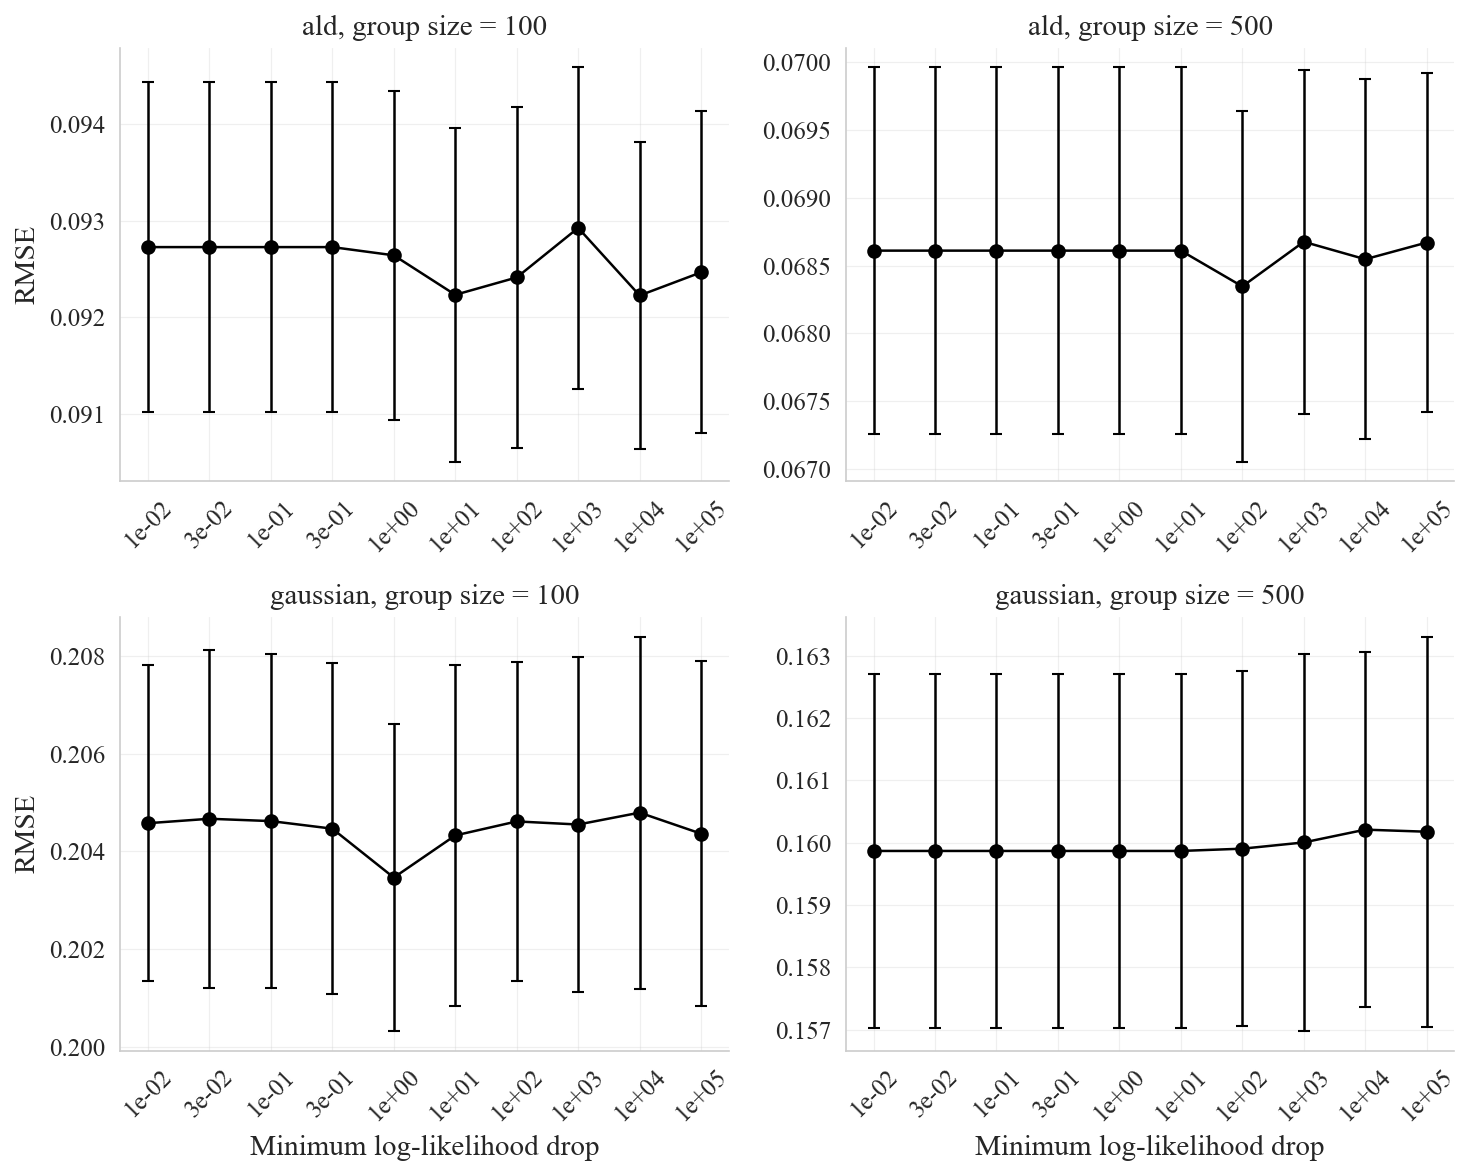

In [135]:
plot_metric(summary, "rmse_mean", "rmse_se", "RMSE")

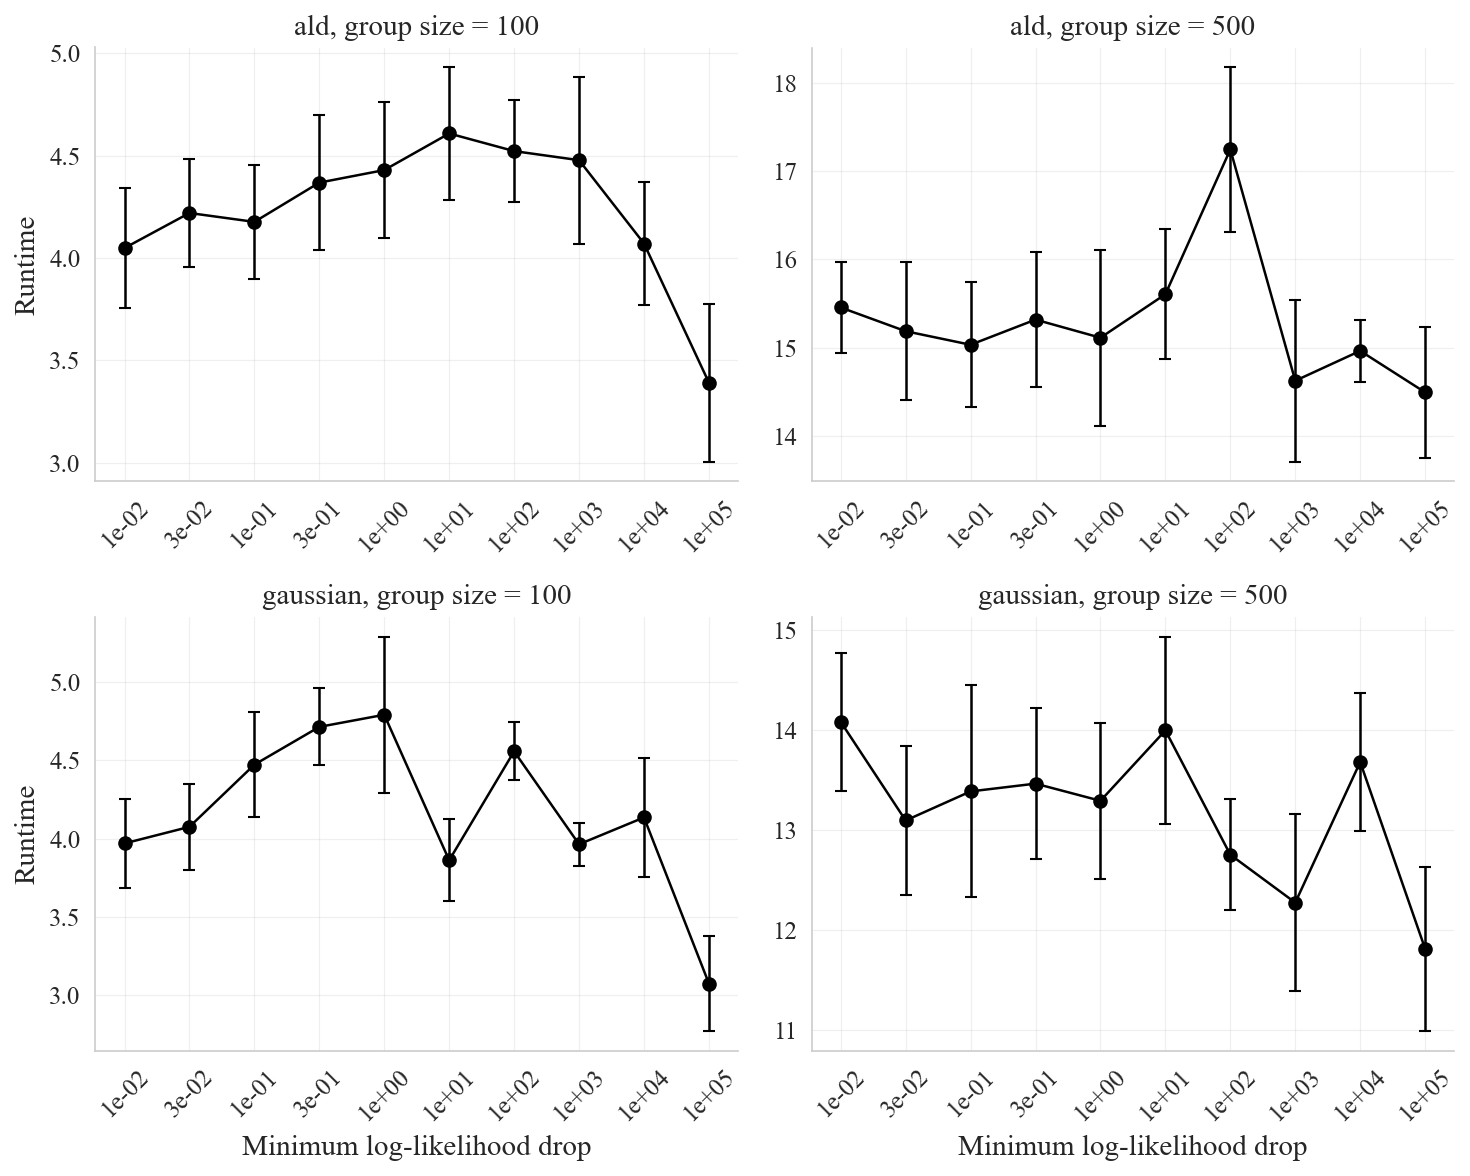

In [136]:
plot_metric(summary, "time_mean", "time_se", "Runtime")

In [137]:
summary.pivot_table(
    index=["likelihood", "group_size"],
    columns="delta_logl",
    values="rmse_mean"
)

delta_logl             0.01       0.03       0.10       0.30       1.00       \
likelihood group_size                                                          
ald        100          0.092726   0.092726   0.092726   0.092726   0.092641   
           500          0.068610   0.068610   0.068610   0.068610   0.068610   
gaussian   100          0.204579   0.204670   0.204623   0.204467   0.203465   
           500          0.159867   0.159867   0.159867   0.159867   0.159867   

delta_logl             10.00      100.00     1000.00    10000.00   100000.00  
likelihood group_size                                                         
ald        100          0.092233   0.092412   0.092924   0.092226   0.092465  
           500          0.068610   0.068347   0.068676   0.068547   0.068670  
gaussian   100          0.204329   0.204616   0.204552   0.204796   0.204365  
           500          0.159867   0.159903   0.160004   0.160209   0.160176

In [138]:
baseline = (
    summary[summary["delta_logl"] == 0.1]
    [["likelihood", "group_size", "rmse_mean", "time_mean"]]
    .rename(columns={"rmse_mean": "rmse_base", "time_mean": "time_base"})
)

comp = summary.merge(baseline, on=["likelihood", "group_size"], how="left")
comp["rmse_diff_vs_0.1"] = comp["rmse_mean"] - comp["rmse_base"]
comp["time_ratio_vs_0.1"] = comp["time_mean"] / comp["time_base"]

comp[["likelihood", "group_size", "delta_logl", "rmse_diff_vs_0.1", "time_ratio_vs_0.1"]]

,likelihood,group_size,delta_logl,rmse_diff_vs_0.1,time_ratio_vs_0.1
0,ald,100,0.01,0.000000,0.969436
1,ald,100,0.03,0.000000,1.010392
2,ald,100,0.10,0.000000,1.000000
3,ald,100,0.30,0.000000,1.045895
4,ald,100,1.00,-0.000085,1.060549
5,ald,100,10.00,-0.000492,1.103308
6,ald,100,100.00,-0.000313,1.082723
7,ald,100,1000.00,0.000198,1.072119
8,ald,100,10000.00,-0.000499,0.974733
9,ald,100,100000.00,-0.000260,0.812165


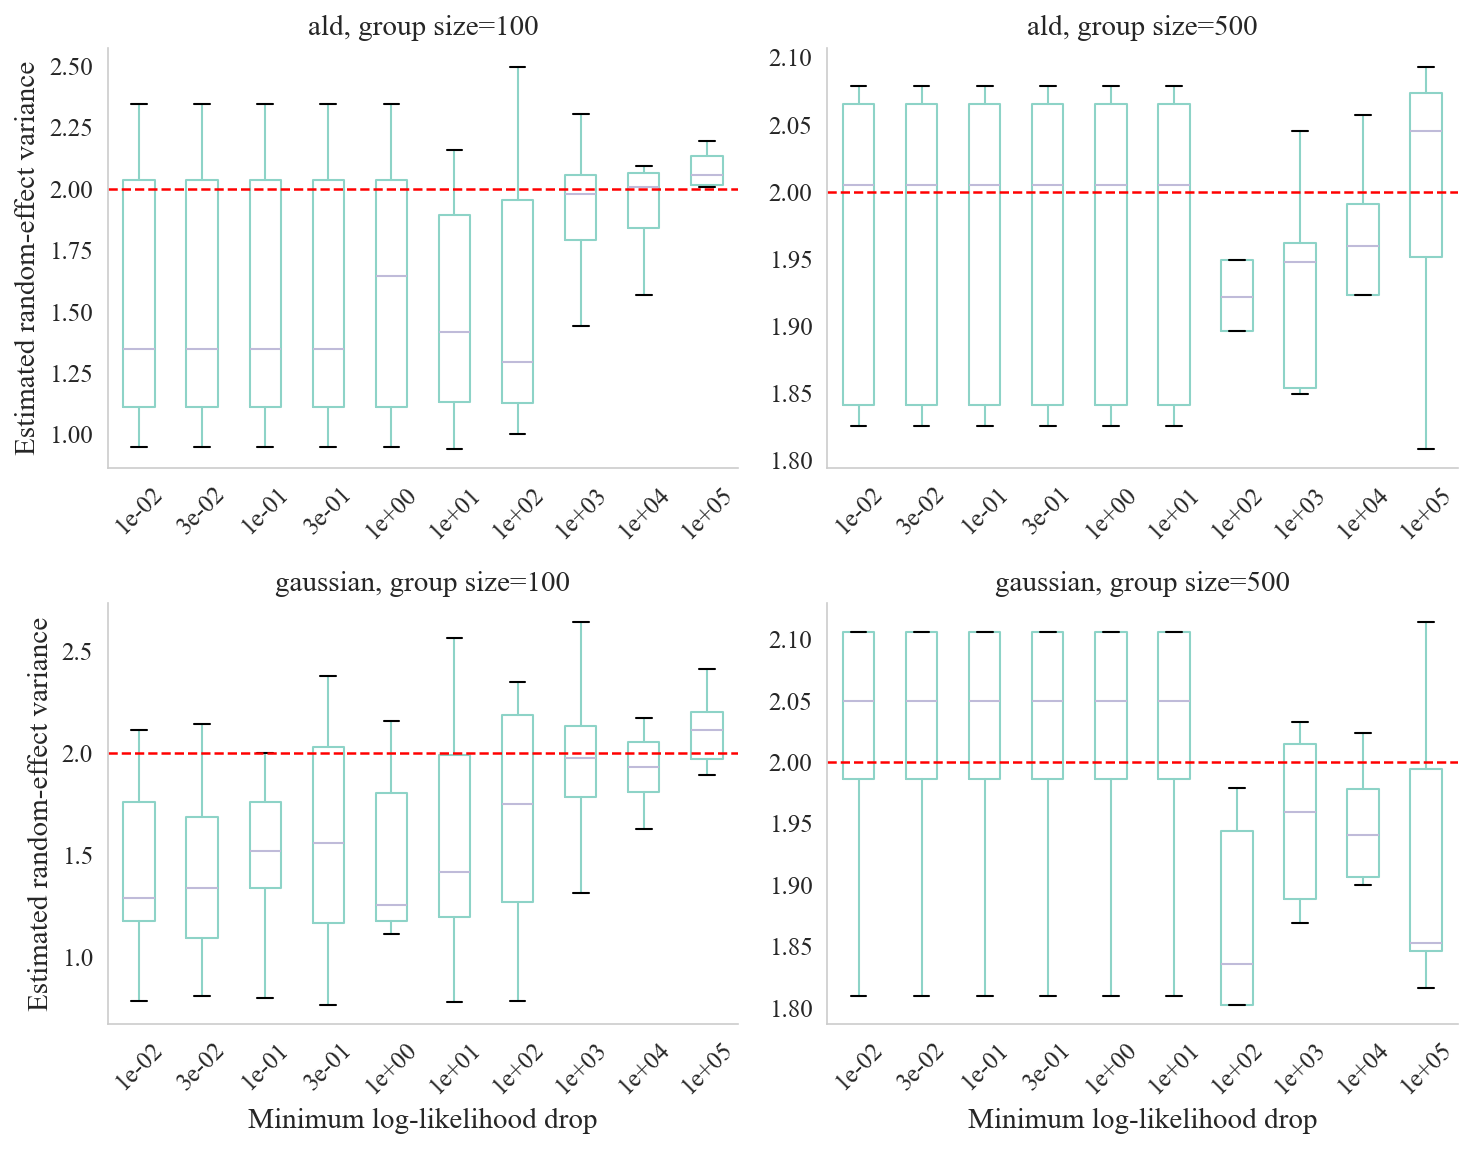

In [142]:
likelihoods = sorted(df["likelihood"].dropna().unique())
group_sizes = sorted(df["group_size"].dropna().unique())

fig, axes = plt.subplots(
    len(likelihoods),
    len(group_sizes),
    figsize=(5 * len(group_sizes), 4 * len(likelihoods)),
    squeeze=False,
    #sharey="row",
    #sharex="col"
)

for i, lik in enumerate(likelihoods):
    for j, gs in enumerate(group_sizes):
        ax = axes[i, j]

        sub = df[
            (df["likelihood"] == lik) &
            (df["group_size"] == gs)
        ][["delta_logl", "hyper_Group_2"]].dropna().copy()

        order = sorted(sub["delta_logl"].unique())
        labels = [f"{x:.0e}" for x in order]
        sub["delta_logl_label"] = pd.Categorical(
            [f"{x:.0e}" for x in sub["delta_logl"]],
            categories=labels,
            ordered=True
        )

        sub.boxplot(
            column="hyper_Group_2",
            by="delta_logl_label",
            ax=ax,
            grid=False,
            showfliers=False, 
        )

        ax.tick_params(axis="x", labelrotation=45)
        ax.axhline(2.0, linestyle="--", color = "red")
        #ax.set_xlabel("Minimum log-likelihood drop", fontsize = 14)
        #ax.set_ylabel("Estimated random-effect variance")
        ax.set_title(f"{lik}, group size={gs}")

        if i == len(likelihoods) - 1:
            ax.set_xlabel("Minimum log-likelihood drop", fontsize = 14)
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel("Estimated random-effect variance")
        else:
            ax.set_ylabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()